<a href="https://colab.research.google.com/github/essanchristian-maker/DI-Bootcamp/blob/master/Week5_Day2_Daily_challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

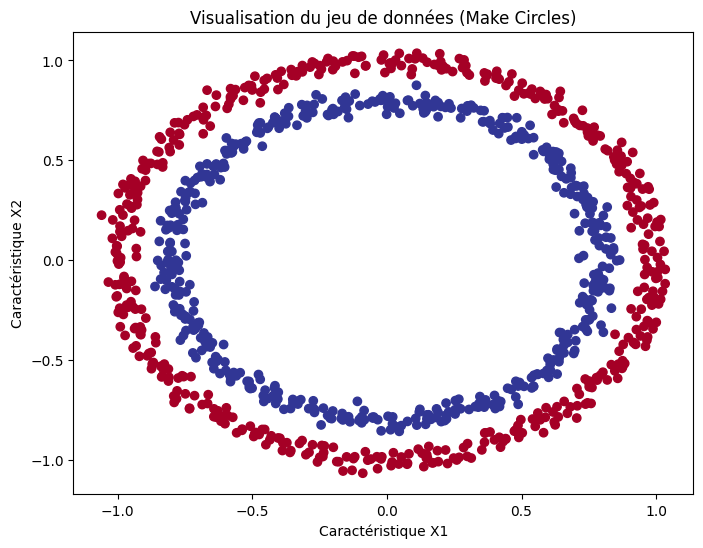

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

# 1. Génération de 1000 échantillons
samples = 1000
X, y = make_circles(samples, noise=0.03, random_state=42)

# 2. Visualisation des données sous forme de graphique à dispersion (Scatter Plot)
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)
plt.title("Visualisation du jeu de données (Make Circles)")
plt.xlabel("Caractéristique X1")
plt.ylabel("Caractéristique X2")
plt.show()

In [2]:
# Fixer la graine aléatoire pour la reproductibilité
tf.random.set_seed(42)

# 1. Création d'un modèle séquentiel de base
base_model = tf.keras.Sequential([
    tf.keras.layers.Dense(1) # Une seule couche avec un neurone
])

# 2. Compilation du modèle avec la descente de gradient stochastique (SGD)
base_model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.SGD(),
    metrics=['accuracy']
)

# 3. Entraînement du modèle
print("Entraînement du modèle de base...")
base_model.fit(X, y, epochs=5, verbose=1)

Entraînement du modèle de base...
Epoch 1/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4870 - loss: 6.2377
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4690 - loss: 5.4188
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4810 - loss: 4.2995
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4800 - loss: 1.0984
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4800 - loss: 0.7088


In [4]:
def plot_decision_boundary(model, X, y):
    """
    Fonction pour tracer la frontière de décision d'un modèle sur les données X.
    """
    # Définir les limites de la grille
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    # Créer des prédictions sur toute la grille
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    pred = model.predict(grid_points)

    # Si la sortie est une probabilité (Sigmoid), on arrondit à 0 ou 1
    if len(pred[0]) == 1:
        pred = np.round(pred)
    else:
        pred = np.argmax(pred, axis=1)

    # Redimensionner et afficher le contour des prédictions
    pred = pred.reshape(xx.shape)
    plt.contourf(xx, yy, pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolors='k')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())


Entraînement du modèle amélioré...

[Résultats sur le jeu de Test] Perte (Loss): 0.0437 - Précision (Accuracy): 98.50%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


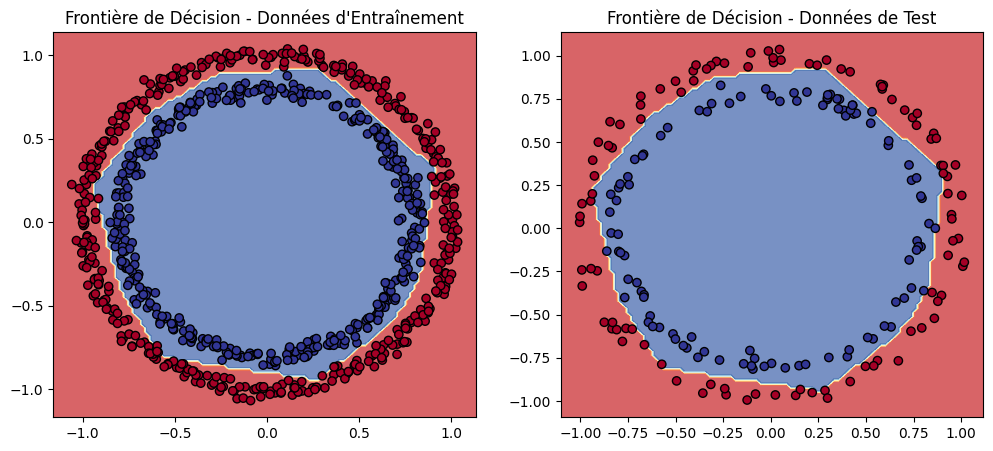

In [5]:
# 1. Division des données (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Construction du modèle profond et non-linéaire
improved_model = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation='relu'), # Couche cachée 1 avec ReLU
    tf.keras.layers.Dense(4, activation='relu'), # Couche cachée 2 avec ReLU
    tf.keras.layers.Dense(1, activation='sigmoid') # Couche de sortie avec Sigmoid
])

# 3. Compilation avec l'optimiseur Adam
improved_model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=['accuracy']
)

# 4. Entraînement sur le jeu d'entraînement pendant 100 époques
print("\nEntraînement du modèle amélioré...")
history = improved_model.fit(X_train, y_train, epochs=100, verbose=0) # verbose=0 pour cacher les lignes

# 5. Évaluation sur le jeu de test
loss, accuracy = improved_model.evaluate(X_test, y_test, verbose=0)
print(f"\n[Résultats sur le jeu de Test] Perte (Loss): {loss:.4f} - Précision (Accuracy): {accuracy * 100:.2f}%")

# 6. Visualisation des frontières de décision
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Frontière de Décision - Données d'Entraînement")
plot_decision_boundary(improved_model, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Frontière de Décision - Données de Test")
plot_decision_boundary(improved_model, X_test, y_test)

plt.show()

**Synthèse des points clés à retenir**


La Non-linéarité est indispensable : Les données du monde réel sont rarement séparables par une simple ligne droite. Sans fonctions d'activation comme ReLU, un réseau de neurones (peu importe sa taille) ne reste qu'une simple combinaison linéaire incapable de résoudre des problèmes complexes comme le jeu de données make_circles.

L'importance de la visualisation : Tracer les données et la frontière de décision permet de comprendre instantanément pourquoi un modèle échoue (par exemple, s'il tente désespérément de tracer une ligne droite au milieu de cercles) et de valider visuellement sa réussite.

Le réglage des hyperparamètres (Tuning) : Passer de l'optimiseur SGD à Adam, ajuster le taux d'apprentissage (learning rate), et augmenter le nombre d'époques et de neurones sont des leviers essentiels pour faire passer la précision d'un modèle de 50% (hasard) à près de 100%.